In [ ]:
import pandas as  pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
!pip install prophet

from prophet import Prophet

In [ ]:
df=pd.read_csv('/content/Walmart DataSet.csv')
print(df)

      Store        Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0         1  05-02-2010    1643690.90             0        42.31       2.572   
1         1  12-02-2010    1641957.44             1        38.51       2.548   
2         1  19-02-2010    1611968.17             0        39.93       2.514   
3         1  26-02-2010    1409727.59             0        46.63       2.561   
4         1  05-03-2010    1554806.68             0        46.50       2.625   
...     ...         ...           ...           ...          ...         ...   
6430     45  28-09-2012     713173.95             0        64.88       3.997   
6431     45  05-10-2012     733455.07             0        64.89       3.985   
6432     45  12-10-2012     734464.36             0        54.47       4.000   
6433     45  19-10-2012     718125.53             0        56.47       3.969   
6434     45  26-10-2012     760281.43             0        58.85       3.882   

             CPI  Unemployment  
0     

In [ ]:


# Convert date
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Sort values
df = df.sort_values(['Store','Date'])

print(df)

      Store       Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0         1 2010-02-05    1643690.90             0        42.31       2.572   
1         1 2010-02-12    1641957.44             1        38.51       2.548   
2         1 2010-02-19    1611968.17             0        39.93       2.514   
3         1 2010-02-26    1409727.59             0        46.63       2.561   
4         1 2010-03-05    1554806.68             0        46.50       2.625   
...     ...        ...           ...           ...          ...         ...   
6430     45 2012-09-28     713173.95             0        64.88       3.997   
6431     45 2012-10-05     733455.07             0        64.89       3.985   
6432     45 2012-10-12     734464.36             0        54.47       4.000   
6433     45 2012-10-19     718125.53             0        56.47       3.969   
6434     45 2012-10-26     760281.43             0        58.85       3.882   

             CPI  Unemployment  
0     211.096358  

In [ ]:


# Convert date
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Sort values
df = df.sort_values(['Store','Date'])

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106


In [ ]:
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [ ]:
Q1 = df['Weekly_Sales'].quantile(0.25)
Q3 = df['Weekly_Sales'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['Weekly_Sales'] >= Q1 - 1.5*IQR) &
        (df['Weekly_Sales'] <= Q3 + 1.5*IQR)]

**EDA & Statistical** **Analysis**

**(a) Impact of Unemployment on Sales**

In [ ]:
df.groupby('Store')[['Weekly_Sales','Unemployment']].corr().iloc[0::2,-1]

,,Unemployment
Store,,
1,Weekly_Sales,-0.097955
2,Weekly_Sales,0.066325
3,Weekly_Sales,-0.230413
4,Weekly_Sales,-0.337015
5,Weekly_Sales,-0.207043
6,Weekly_Sales,0.044251
7,Weekly_Sales,-0.165382
8,Weekly_Sales,-0.052580
9,Weekly_Sales,-0.191534


**Stores Suffering Most:**

In [ ]:
corr_store = df.groupby('Store').apply(
    lambda x: x['Weekly_Sales'].corr(x['Unemployment'])
).sort_values()

corr_store.head()

/tmp/ipykernel_2606/3827699383.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  corr_store = df.groupby('Store').apply(


,0
Store,
38,-0.785290
44,-0.780076
39,-0.384681
42,-0.356355
41,-0.350630


**(b) Seasonal Trend**

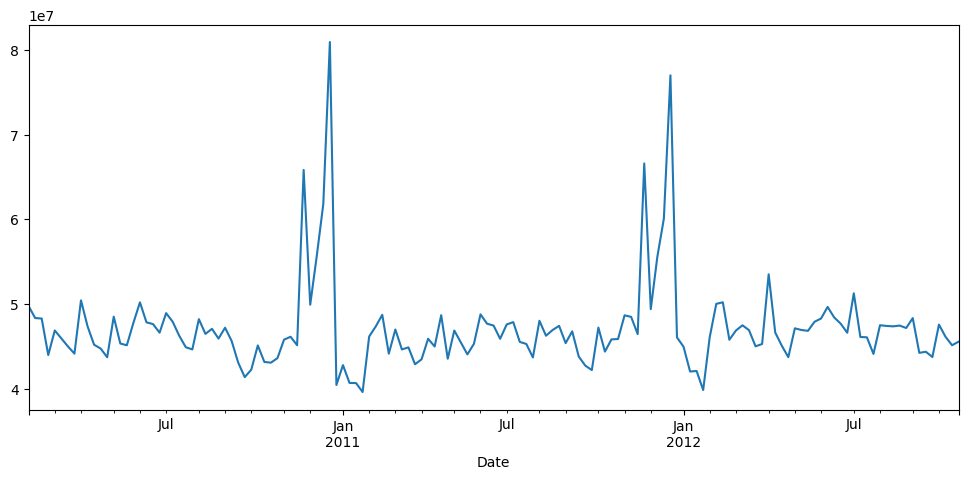

In [ ]:
import matplotlib.pyplot as plt

df.groupby('Date')['Weekly_Sales'].sum().plot(figsize=(12,5))
plt.show()

**(c) Temperature Effect**

In [ ]:
df[['Weekly_Sales','Temperature']].corr()

,Weekly_Sales,Temperature
Weekly_Sales,1.00000,-0.06381
Temperature,-0.06381,1.00000


**(d) CPI Impact**

In [ ]:
df[['Weekly_Sales','CPI']].corr()

,Weekly_Sales,CPI
Weekly_Sales,1.000000,-0.072634
CPI,-0.072634,1.000000


**(e) Top Performing Stores**

In [ ]:
top_stores = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)
top_stores.head()

,Weekly_Sales
Store,
20,3.013978e+08
4,2.995440e+08
14,2.889999e+08
13,2.865177e+08
2,2.753824e+08


**(f) Worst Store & Performance Gap**

In [ ]:
worst_store = top_stores.idxmin()
best_store = top_stores.idxmax()

difference = top_stores.max() - top_stores.min()

best_store, worst_store, difference

(np.int64(20), np.int64(33), 264237570.49999997)

**Forecasting (Next 12 Weeks)**

**Forecast for Each Store**

In [ ]:
forecast_results = {}

for store in df['Store'].unique():

    store_df = df[df['Store'] == store][['Date','Weekly_Sales']]
    store_df.columns = ['ds','y']

    model = Prophet()
    model.fit(store_df)

    future = model.make_future_dataframe(periods=12, freq='W')
    forecast = model.predict(future)

    forecast_results[store] = forecast[['ds','yhat']].tail(12)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to overr

**View Forecast**

In [ ]:
forecast_results[1].head()   # Example for Store 1

,ds,yhat
143,2012-10-28,1.533722e+06
144,2012-11-04,1.599967e+06
145,2012-11-11,1.690155e+06
146,2012-11-18,1.747222e+06
147,2012-11-25,1.768337e+06


**Plot Forecast**

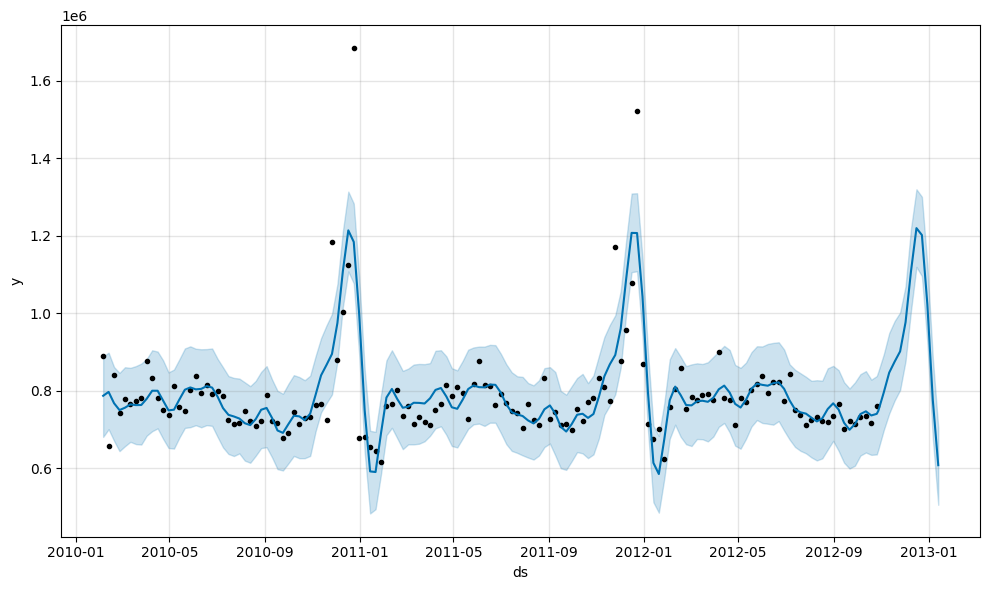

In [ ]:
model.plot(forecast)
plt.show()